# Week 1

**Get datasets for iNaturalist data, Snapshot Serengeti - Suhana**

Snapshot Serengeti

In [ ]:
!ls -lh SnapshotSerengetiS03.json SnapshotSerengetiS03.json.zip || true

-rw-rw-rw- 1 root root 293M Jun 23  2019 SnapshotSerengetiS03.json
-rw-r--r-- 1 root root  19M May 21 03:42 SnapshotSerengetiS03.json.zip


In [ ]:
import json

with open("SnapshotSerengetiS03.json") as f:
    s03 = json.load(f)

print(f"Images:      {len(s03['images'])}")
print(f"Annotations: {len(s03['annotations'])}")
print(f"Categories:  {len(s03['categories'])}")

Images:      392507
Annotations: 398689
Categories:  61


In [ ]:
# See what an image record looks like
print(s03['images'][0])
# {'id': '...', 'file_name': 'S3/B04/B04_R1/S3_B04_R1_PICT0001.JPG', ...}

# See available species labels
for cat in s03['categories'][:10]:
    print(cat)

{'id': 'S3/I03/I03_R12/S3_I03_R12_IMAG1453', 'file_name': 'S3/I03/I03_R12/S3_I03_R12_IMAG1453.JPG', 'frame_num': 3, 'seq_id': 'SER_S3#I03#12#519', 'width': 2048, 'height': 1536, 'corrupt': False, 'location': 'I03', 'seq_num_frames': 3, 'datetime': '2011-12-25 16:17:48'}
{'id': 0, 'name': 'empty'}
{'id': 1, 'name': 'human'}
{'id': 2, 'name': 'gazellegrants'}
{'id': 3, 'name': 'reedbuck'}
{'id': 4, 'name': 'dikdik'}
{'id': 5, 'name': 'zebra'}
{'id': 6, 'name': 'porcupine'}
{'id': 7, 'name': 'gazellethomsons'}
{'id': 8, 'name': 'hyenaspotted'}
{'id': 9, 'name': 'warthog'}


In [ ]:
# Map image_id -> category (species label)
id_to_category = {cat['id']: cat['name'] for cat in s03['categories']}

image_to_label = {}
for ann in s03['annotations']:
    image_to_label[ann['image_id']] = id_to_category[ann['category_id']]

# Pair each image with its label
image_records = [
    {
        "file_name": img["file_name"],
        "label": image_to_label.get(img["id"], "unknown")
    }
    for img in s03["images"]
]

print(image_records[0])
# {'file_name': 'S3/B04/...JPG', 'label': 'wildebeest'}

{'file_name': 'S3/I03/I03_R12/S3_I03_R12_IMAG1453.JPG', 'label': 'empty'}


In [ ]:
import tensorflow as tf

GCS_ROOT = "gs://public-datasets-lila/snapshotserengeti-unzipped/"

def load_and_preprocess(file_name, label):
    img_bytes = tf.io.read_file(GCS_ROOT + file_name)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0  # normalize to [0, 1]
    return img, label

# Pull file names and labels into lists
file_names = []
labels = []

for r in image_records:
  if r["label"] != "empty":
    file_names.append(r["file_name"])
    labels.append(r["label"])

# Build the streaming dataset
dataset = tf.data.Dataset.from_tensor_slices((file_names, labels))
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)

print(f"Total images: {len(file_names)}")

Total images: 121658


In [ ]:
#discard the empty labelled data


In [ ]:
#data imbalances

counts = {}
for label in labels:
  if label in counts.keys():
    counts[label] += 1
  else:
    counts[label] = 1

print(counts)

{'wildebeest': 42283, 'zebra': 28519, 'gazellethomsons': 15612, 'buffalo': 4603, 'hartebeest': 3314, 'impala': 2007, 'warthog': 2157, 'otherbird': 869, 'guineafowl': 1903, 'lionfemale': 1343, 'human': 4139, 'elephant': 3177, 'giraffe': 3060, 'gazellegrants': 2687, 'ostrich': 511, 'hyenaspotted': 1132, 'eland': 810, 'topi': 694, 'dikdik': 225, 'lionmale': 254, 'baboon': 630, 'caracal': 8, 'reedbuck': 392, 'cheetah': 245, 'hippopotamus': 412, 'leopard': 29, 'aardvark': 63, 'monkeyvervet': 72, 'jackal': 34, 'secretarybird': 84, 'serval': 44, 'bushbuck': 38, 'koribustard': 141, 'zorilla': 3, 'hyenastriped': 16, 'waterbuck': 14, 'honeybadger': 9, 'aardwolf': 10, 'porcupine': 47, 'mongoose': 21, 'hare': 18, 'batearedfox': 9, 'rodents': 4, 'rhinoceros': 7, 'civet': 4, 'genet': 5}


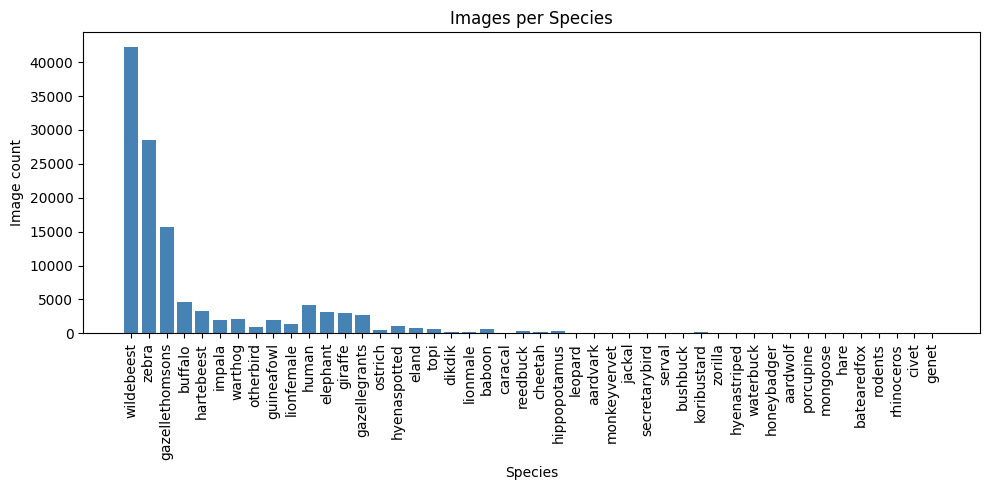

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.title("Images per Species")
plt.xlabel("Species")
plt.ylabel("Image count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
!pip install gcsfs -q

import gcsfs
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from io import BytesIO

GCS_BUCKET = "gs://public-datasets-lila/snapshotserengeti-unzipped/"

fs = gcsfs.GCSFileSystem(token="anon")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class SerengetiDataset(Dataset):
    def __init__(self, df, species_to_idx, transform=None):
        self.df             = df.reset_index(drop=True)
        self.species_to_idx = species_to_idx
        self.transform      = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        gcs_path = GCS_BUCKET + row["file_name"]

        # Create a fresh filesystem connection per call — fork-safe
        fs = gcsfs.GCSFileSystem(anon=True)
        with fs.open(gcs_path, "rb") as f:
            img = Image.open(BytesIO(f.read())).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = self.species_to_idx[row["label"]]
        return img, label

from sklearn.model_selection import train_test_split
import torchvision.models as models
import torch.nn as nn

# Filter out empty images before doing anything else
filtered_df = s03_df[s03_df["label"] != "empty"].dropna(subset=["label"])
print(f"Images after removing 'empty': {len(filtered_df):,}")

train_df, val_df = train_test_split(
    filtered_df,
    test_size=0.2,
    random_state=42,
    stratify=filtered_df["label"]
)

# Rebuild species list and label encodings without "empty"
species_list   = sorted(filtered_df["label"].unique())
species_to_idx = {name: idx for idx, name in enumerate(species_list)}
idx_to_species = {idx: name for name, idx in species_to_idx.items()}

train_dataset = SerengetiDataset(train_df, species_to_idx, transform=transform)
val_dataset   = SerengetiDataset(val_df,   species_to_idx, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Example labels: {[idx_to_species[l.item()] for l in labels[:5]]}")

Images after removing 'empty': 121,658


KeyboardInterrupt: 

iNaturalist Data

In [ ]:
import pandas as pd

# taxa.csv is small (~50MB) — safe to load fully
taxa = pd.read_csv(
    "https://inaturalist-open-data.s3.amazonaws.com/taxa.csv.gz",
    sep="\t",
    compression="gzip",
    on_bad_lines="skip"
)
print(f"Taxa loaded: {len(taxa):,} rows")

# photos.csv is medium sized — load fully
photos = pd.read_csv(
    "https://inaturalist-open-data.s3.amazonaws.com/photos.csv.gz",
    sep="\t",
    compression="gzip",
    on_bad_lines="skip"
)
print(f"Photos loaded: {len(photos):,} rows")

Taxa loaded: 1,635,878 rows


In [ ]:
# Stream observations.csv in chunks, keeping only 2026 rows
# This means only one chunk (~100k rows) lives in RAM at any moment
chunks = []

for chunk in pd.read_csv(
    "https://inaturalist-open-data.s3.amazonaws.com/observations.csv.gz",
    sep="\t",
    compression="gzip",
    chunksize=100_000,
    on_bad_lines="skip"
):
    mask = chunk["observed_on"].str.startswith("2026", na=False)
    chunks.append(chunk[mask])

obs_2026 = pd.concat(chunks, ignore_index=True)
print(f"2026 observations: {len(obs_2026):,}")

In [ ]:
!pip install duckdb -q
import duckdb

# Extract observations.csv from the archive to a temporary in-memory buffer
obs_buffer = BytesIO(tar.extractfile("observations.csv").read())

# Write it temporarily so DuckDB can query it
# (DuckDB needs a file path or dataframe — we use a temp file here)
with open("/tmp/observations.csv", "wb") as f:
    f.write(obs_buffer.read())

obs_2026 = duckdb.query("""
    SELECT *
    FROM read_csv('/tmp/observations.csv', delim='\t', header=true)
    WHERE observed_on LIKE '2026%'
""").df()

print(f"2026 observations: {len(obs_2026):,}")

In [ ]:
merged_2026 = (
    obs_2026
    .merge(photos[["photo_id", "observation_uuid", "extension"]], on="observation_uuid")
    .merge(taxa[["taxon_id", "name", "common_name"]], on="taxon_id")
    .dropna(subset=["name", "photo_id", "extension"])
    .reset_index(drop=True)
)

print(f"Total photos available: {len(merged_2026):,}")
print(merged_2026[["photo_id", "extension", "name", "common_name", "observed_on"]].head())

In [ ]:
species_list   = sorted(merged_2026["name"].unique())
species_to_idx = {name: idx for idx, name in enumerate(species_list)}
idx_to_species = {idx: name for name, idx in species_to_idx.items()}

print(f"Number of species (classes): {len(species_list)}")

In [ ]:
!pip install torch torchvision -q

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Standard preprocessing for pretrained models:
# resize to 224x224, convert to tensor, normalize using ImageNet mean/std
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class iNaturalistDataset(Dataset):
    def __init__(self, df, species_to_idx, transform=None, size="medium"):
        self.df            = df.reset_index(drop=True)
        self.species_to_idx = species_to_idx
        self.transform     = transform
        self.size          = size  # options: original, large, medium, small, thumb, square

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Build the public S3 URL for this photo
        url = f"https://inaturalist-open-data.s3.amazonaws.com/photos/{row['photo_id']}/{self.size}.{row['extension']}"

        # Fetch image bytes from S3 and decode — nothing saved to disk
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = self.species_to_idx[row["name"]]

        return img, label

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    merged_2026,
    test_size=0.2,
    random_state=42,
    stratify=merged_2026["name"]
)

print(f"Training samples:   {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")

train_dataset = iNaturalistDataset(train_df, species_to_idx, transform=transform)
val_dataset   = iNaturalistDataset(val_df,   species_to_idx, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}")   # should be [32, 3, 224, 224]
print(f"Label batch shape: {labels.shape}")   # should be [32]
print(f"Example species:   {[idx_to_species[l.item()] for l in labels[:5]]}")

**Try to load in SpeciesNet, the Snapshot Serengeti classifer - Natalie**

In [ ]:
# Install download helpers
!pip -q install kagglehub gdown speciesnet

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 324, in run
    session = self.get_default_session(options)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 71, in get_default_session
    self._session = self.enter_context(self._build_session(options))
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/index_command.py", line 100, in _build_session
    session = PipSession(
              ^^^^^^^^^

In [ ]:
# Download SpeciesNet classifier weights from Kaggle
# 4.0.2a = crop classifier, 4.0.2b = whole-image classifier
import kagglehub, os

speciesnet_crop_dir = kagglehub.model_download("google/speciesnet/pyTorch/v4.0.2a/1")
speciesnet_whole_dir = kagglehub.model_download("google/speciesnet/pyTorch/v4.0.2b/1")

print("SpeciesNet crop classifier:", speciesnet_crop_dir)
print("SpeciesNet whole-image classifier:", speciesnet_whole_dir)
print(os.listdir(speciesnet_crop_dir))
print(os.listdir(speciesnet_whole_dir))

SpeciesNet crop classifier: /kaggle/input/speciesnet/pytorch/v4.0.2a/1
SpeciesNet whole-image classifier: /kaggle/input/speciesnet/pytorch/v4.0.2b/1
['always_crop_99710272_22x8_v12_epoch_00148.pt', 'README.md', 'info.json', 'taxonomy_release.20251208.txt', 'always_crop_99710272_22x8_v12_epoch_00148.labels.20251208.txt', 'geofence_release.20251208.json']
['full_image_88545560_22x8_v12_epoch_00153.labels.20251208.txt', 'README.md', 'info.json', 'taxonomy_release.20251208.txt', 'full_image_88545560_22x8_v12_epoch_00153.pt', 'geofence_release.20251208.json']


In [ ]:
# Download Snapshot Serengeti pretrained classifiers
# Source: Evolving-AI-Lab/deep_learning_for_camera_trap_images

import os, gdown

os.makedirs("/content/snapshot_serengeti_models", exist_ok=True)

snapshot_models = {
    "phase1_vgg.zip": "1Y-aDWNMfvgYUb-u-_cqzibZ6ePFOOLGj",
    "phase2_resnet152.zip": "1KTV9dmqkv0xrheIOEkPXbqeg36_rXJ_E",
    "phase2_recognition_only_resnet152.zip": "1cAcnyBTO5JeB2zSaEoGBWf0Jd-jAnguS",
}

for filename, file_id in snapshot_models.items():
    out = f"/content/snapshot_serengeti_models/{filename}"
    gdown.download(id=file_id, output=out, quiet=False)

print(os.listdir("/content/snapshot_serengeti_models"))

Downloading...
From (original): https://drive.google.com/uc?id=1Y-aDWNMfvgYUb-u-_cqzibZ6ePFOOLGj
From (redirected): https://drive.google.com/uc?id=1Y-aDWNMfvgYUb-u-_cqzibZ6ePFOOLGj&confirm=t&uuid=c2398618-0049-46cb-9a1e-84d01a1be0ab
To: /content/snapshot_serengeti_models/phase1_vgg.zip
100%|██████████| 1.15G/1.15G [00:17<00:00, 64.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1KTV9dmqkv0xrheIOEkPXbqeg36_rXJ_E
From (redirected): https://drive.google.com/uc?id=1KTV9dmqkv0xrheIOEkPXbqeg36_rXJ_E&confirm=t&uuid=83198273-2353-4f22-92a2-04ed572db97e
To: /content/snapshot_serengeti_models/phase2_resnet152.zip
100%|██████████| 667M/667M [00:07<00:00, 93.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1cAcnyBTO5JeB2zSaEoGBWf0Jd-jAnguS
From (redirected): https://drive.google.com/uc?id=1cAcnyBTO5JeB2zSaEoGBWf0Jd-jAnguS&confirm=t&uuid=833bd16e-279c-4d8d-b995-f74cc9486c07
To: /content/snapshot_serengeti_models/phase2_recognition_only_resnet152.zip
100%|█

['phase2_recognition_only_resnet152.zip', 'phase1_vgg.zip', 'phase2_resnet152.zip']


In [ ]:
# Optional: unzip Snapshot Serengeti models
!mkdir -p /content/snapshot_serengeti_models/unzipped
!unzip -q "/content/snapshot_serengeti_models/*.zip" -d /content/snapshot_serengeti_models/unzipped || true
!find /content/snapshot_serengeti_models -maxdepth 3 -type f | head -50


3 archives were successfully processed.
/content/snapshot_serengeti_models/phase2_recognition_only_resnet152.zip
/content/snapshot_serengeti_models/phase1_vgg.zip
/content/snapshot_serengeti_models/phase2_resnet152.zip
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/snapshot-55.index
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/snapshot-55.meta
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/checkpoint
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/snapshot-55.data-00000-of-00001
/content/snapshot_serengeti_models/unzipped/phase2/snapshot-55.index
/content/snapshot_serengeti_models/unzipped/phase2/snapshot-55.meta
/content/snapshot_serengeti_models/unzipped/phase2/checkpoint
/content/snapshot_serengeti_models/unzipped/phase2/snapshot-55.data-00000-of-00001
/content/snapshot_serengeti_models/unzipped/phase1/snapshot-55.index
/content/snapshot_serengeti_models/unzipped/phase1/snapshot-55.meta
/content/sn

In [ ]:
# ==============================
# SPECIESNET SAFE-ish LOAD CHECK
# ==============================

import torch
import glob
import os

# Find all .pt files
speciesnet_weight_files = glob.glob(
    "/root/.cache/kagglehub/models/google/speciesnet/**/*.pt",
    recursive=True
)

# Remove duplicates
speciesnet_weight_files = sorted(set(speciesnet_weight_files))

print("Unique SpeciesNet files found:", len(speciesnet_weight_files))

for path in speciesnet_weight_files:
    print("\nChecking:", path)
    print("Size MB:", round(os.path.getsize(path) / 1024 / 1024, 2))

    try:
        # Safe here because these are official Google checkpoints
        model = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        print("✅ Loaded successfully")
        print("Object type:", type(model))

    except Exception as e:
        print("❌ Load failed:", e)

Unique SpeciesNet files found: 2

Checking: /root/.cache/kagglehub/models/google/speciesnet/pyTorch/v4.0.2a/1/always_crop_99710272_22x8_v12_epoch_00148.pt
Size MB: 214.0
✅ Loaded successfully
Object type: <class 'torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl'>

Checking: /root/.cache/kagglehub/models/google/speciesnet/pyTorch/v4.0.2b/1/full_image_88545560_22x8_v12_epoch_00153.pt
Size MB: 214.0
✅ Loaded successfully
Object type: <class 'torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl'>


In [ ]:
# ==========================================
# SNAPSHOT SERENGETI TENSORFLOW CHECKPOINT CHECK
# ==========================================

import os
import glob

base_dir = "/content/snapshot_serengeti_models/unzipped"

print("Snapshot Serengeti extracted folders:")
print(os.listdir(base_dir))

checkpoint_files = glob.glob(
    os.path.join(base_dir, "**", "checkpoint"),
    recursive=True
)

meta_files = glob.glob(
    os.path.join(base_dir, "**", "*.meta"),
    recursive=True
)

index_files = glob.glob(
    os.path.join(base_dir, "**", "*.index"),
    recursive=True
)

data_files = glob.glob(
    os.path.join(base_dir, "**", "*.data-*"),
    recursive=True
)

print("\nCheckpoint files:", len(checkpoint_files))
print("Meta files:", len(meta_files))
print("Index files:", len(index_files))
print("Data files:", len(data_files))

if checkpoint_files and meta_files and index_files and data_files:
    print("\n✅ Snapshot Serengeti TensorFlow checkpoints look complete")
else:
    print("\n❌ Something is missing")

for f in checkpoint_files + meta_files + index_files + data_files:
    print(f, round(os.path.getsize(f) / 1024 / 1024, 2), "MB")

Snapshot Serengeti extracted folders:
['phase2_recognition_only', 'phase2', 'phase1']

Checkpoint files: 3
Meta files: 3
Index files: 3
Data files: 3

✅ Snapshot Serengeti TensorFlow checkpoints look complete
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/checkpoint 0.0 MB
/content/snapshot_serengeti_models/unzipped/phase2/checkpoint 0.0 MB
/content/snapshot_serengeti_models/unzipped/phase1/checkpoint 0.0 MB
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/snapshot-55.meta 82.69 MB
/content/snapshot_serengeti_models/unzipped/phase2/snapshot-55.meta 189.42 MB
/content/snapshot_serengeti_models/unzipped/phase1/snapshot-55.meta 111.11 MB
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/snapshot-55.index 0.08 MB
/content/snapshot_serengeti_models/unzipped/phase2/snapshot-55.index 0.08 MB
/content/snapshot_serengeti_models/unzipped/phase1/snapshot-55.index 0.0 MB
/content/snapshot_serengeti_models/unzipped/phase2_recognition_only/sn

In [ ]:
# ====================================
# OPTIONAL: READ TF CHECKPOINT VARIABLES
# ====================================

import tensorflow as tf
import glob
import os

ckpt_prefixes = []

for index_file in glob.glob(
    "/content/snapshot_serengeti_models/unzipped/**/*.index",
    recursive=True
):
    ckpt_prefixes.append(index_file.replace(".index", ""))

for ckpt in ckpt_prefixes:
    print("\nChecking TensorFlow checkpoint:", ckpt)

    try:
        vars_in_ckpt = tf.train.list_variables(ckpt)
        print("✅ TensorFlow checkpoint readable")
        print("Number of variables:", len(vars_in_ckpt))
        print("First 10 variables:")
        for name, shape in vars_in_ckpt[:10]:
            print(" ", name, shape)
    except Exception as e:
        print("❌ TensorFlow checkpoint read failed:", e)


Checking TensorFlow checkpoint: /content/snapshot_serengeti_models/unzipped/phase2_recognition_only/snapshot-55
✅ TensorFlow checkpoint readable
Number of variables: 2175
First 10 variables:
  epoch_number []
  output/biases [48]
  output/biases/Momentum [48]
  output/weights [2048, 48]
  output/weights/Momentum [2048, 48]
  scale1/beta [64]
  scale1/beta/Momentum [64]
  scale1/biases [64]
  scale1/biases/Momentum [64]
  scale1/gamma [64]

Checking TensorFlow checkpoint: /content/snapshot_serengeti_models/unzipped/phase2/snapshot-55
✅ TensorFlow checkpoint readable
Number of variables: 2203
First 10 variables:
  epoch_number []
  output0/biases [48]
  output0/biases/Momentum [48]
  output0/weights [2048, 48]
  output0/weights/Momentum [2048, 48]
  output1/biases [12]
  output1/biases/Momentum [12]
  output1/weights [2048, 12]
  output1/weights/Momentum [2048, 12]
  output2/biases [2]

Checking TensorFlow checkpoint: /content/snapshot_serengeti_models/unzipped/phase1/snapshot-55
✅ Tens

**Setup the ALIA pipeline - diffusion models for background/weather changes etc. -
Carolyn**

In [ ]:
# Clone the ALIA repository
!git clone https://github.com/lisadunlap/ALIA.git

import sys
import os

alia_repo_path = os.path.abspath('./ALIA')
if alia_repo_path not in sys.path:
    sys.path.insert(0, alia_repo_path)

print("\nContents of ALIA directory:")
!ls -F ALIA

if os.path.exists('ALIA/requirements.txt'):
    print("\nInstalling dependencies from ALIA/requirements.txt...")
    !pip install -r ALIA/requirements.txt
else:
    print("\nNo requirements.txt found directly in ALIA directory. Please check the directory contents above.")

In [ ]:
# ==============================
# Week 2 - Natalie
# Fine-tune SpeciesNet on Snapshot Serengeti + iNaturalist additions
# ==============================

import os, json, random, shutil, requests
from pathlib import Path
from io import BytesIO

import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

NATALIE_ROOT = ARTIFACT_ROOT / "week2_natalie_speciesnet"
IMG_ROOT = NATALIE_ROOT / "images"
SNAPSHOT_LOCAL_ROOT = IMG_ROOT / "snapshot"
INAT_LOCAL_ROOT = IMG_ROOT / "inat"

for p in [NATALIE_ROOT, SNAPSHOT_LOCAL_ROOT, INAT_LOCAL_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Pick underrepresented Snapshot Serengeti classes.
# Adjust this list after looking at your counts chart.
TARGET_CLASSES = [
    "reedbuck",
    "dikdik",
    "porcupine",
    "hyenaspotted",
    "warthog",
    "buffalo",
    "hartebeest",
    "impala",
    "giraffe",
    "elephant",
    "lionfemale",
    "cheetah",
    "leopard"
]

MAX_SNAPSHOT_PER_CLASS = 300
MAX_INAT_PER_CLASS = 300
TEST_SIZE = 0.2
VAL_SIZE = 0.1
BATCH_SIZE = 64
NUM_EPOCHS_HEAD = 5
NUM_EPOCHS_UNFREEZE = 1
LR_HEAD = 1e-3
LR_UNFREEZE = 1e-5

device = "cuda" if torch.cuda.is_available() else "cpu"

USE_AMP = device == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print("Device:", device)

Device: cuda


In [ ]:
# Rebuild Snapshot Serengeti dataframe from s03 JSON already loaded in Week 1

id_to_category = {cat["id"]: cat["name"] for cat in s03["categories"]}

image_to_label = {}
for ann in s03["annotations"]:
    image_to_label[ann["image_id"]] = id_to_category[ann["category_id"]]

snapshot_rows = []
for img in s03["images"]:
    label = image_to_label.get(img["id"], "unknown")
    if label != "empty" and label in TARGET_CLASSES:
        snapshot_rows.append({
            "source": "snapshot",
            "file_name": img["file_name"],
            "final_label": label
        })

snapshot_df = pd.DataFrame(snapshot_rows)
print(snapshot_df["final_label"].value_counts())
print("Total target Snapshot images:", len(snapshot_df))

final_label
buffalo         4603
hartebeest      3314
elephant        3177
giraffe         3060
warthog         2157
impala          2007
lionfemale      1343
hyenaspotted    1132
reedbuck         392
cheetah          245
dikdik           225
porcupine         47
leopard           29
Name: count, dtype: int64
Total target Snapshot images: 21731


In [ ]:
# Downsample large classes so training is not dominated by a few species

balanced_snapshot = (
    snapshot_df
    .groupby("final_label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_SNAPSHOT_PER_CLASS), random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

trainval_df, test_df = train_test_split(
    balanced_snapshot,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=balanced_snapshot["final_label"]
)

train_df, val_df = train_test_split(
    trainval_df,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=trainval_df["final_label"]
)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

snapshot_split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
snapshot_split_df.to_csv(NATALIE_ROOT / "snapshot_split_metadata.csv", index=False)

print(snapshot_split_df.groupby(["split", "final_label"]).size())

split  final_label 
test   buffalo          60
       cheetah          49
       dikdik           45
       elephant         60
       giraffe          60
       hartebeest       60
       hyenaspotted     60
       impala           60
       leopard           6
       lionfemale       60
       porcupine        10
       reedbuck         60
       warthog          60
train  buffalo         216
       cheetah         176
       dikdik          162
       elephant        216
       giraffe         216
       hartebeest      216
       hyenaspotted    216
       impala          216
       leopard          21
       lionfemale      216
       porcupine        33
       reedbuck        216
       warthog         216
val    buffalo          24
       cheetah          20
       dikdik           18
       elephant         24
       giraffe          24
       hartebeest       24
       hyenaspotted     24
       impala           24
       leopard           2
       lionfemale       24
       p

/tmp/ipykernel_12135/543877279.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_SNAPSHOT_PER_CLASS), random_state=RANDOM_SEED))


In [ ]:
# Manually map Snapshot labels to iNaturalist taxon names.
# You can add/remove names if your TARGET_CLASSES changes.

SNAPSHOT_TO_INAT = {
    "reedbuck": "Redunca redunca",
    "dikdik": "Madoqua kirkii",
    "porcupine": "Hystrix cristata",
    "hyenaspotted": "Crocuta crocuta",
    "warthog": "Phacochoerus africanus",
    "buffalo": "Syncerus caffer",
    "hartebeest": "Alcelaphus buselaphus",
    "impala": "Aepyceros melampus",
    "giraffe": "Giraffa camelopardalis",
    "elephant": "Loxodonta africana",
    "lionfemale": "Panthera leo",
    "cheetah": "Acinonyx jubatus",
    "leopard": "Panthera pardus",
}

pd.DataFrame(
    [{"snapshot_label": k, "inat_name": v} for k, v in SNAPSHOT_TO_INAT.items()]
).to_csv(NATALIE_ROOT / "species_mapping.csv", index=False)

SNAPSHOT_TO_INAT

{'reedbuck': 'Redunca redunca',
 'dikdik': 'Madoqua kirkii',
 'porcupine': 'Hystrix cristata',
 'hyenaspotted': 'Crocuta crocuta',
 'warthog': 'Phacochoerus africanus',
 'buffalo': 'Syncerus caffer',
 'hartebeest': 'Alcelaphus buselaphus',
 'impala': 'Aepyceros melampus',
 'giraffe': 'Giraffa camelopardalis',
 'elephant': 'Loxodonta africana',
 'lionfemale': 'Panthera leo',
 'cheetah': 'Acinonyx jubatus',
 'leopard': 'Panthera pardus'}

In [ ]:
# Load iNaturalist taxa/photos/observations metadata
# This filters to ONLY the species we need.

import pandas as pd

taxa = pd.read_csv(
    "https://inaturalist-open-data.s3.amazonaws.com/taxa.csv.gz",
    sep="\t",
    compression="gzip",
    on_bad_lines="skip"
)

target_inat_names = set(SNAPSHOT_TO_INAT.values())

target_taxa = taxa[taxa["name"].isin(target_inat_names)][
    ["taxon_id", "name"]
].drop_duplicates()

print(target_taxa)

        taxon_id                    name
25907      42278      Aepyceros melampus
27298      42418   Alcelaphus buselaphus
27301      42405         Syncerus caffer
27322      42304         Redunca redunca
31648      42360          Madoqua kirkii
32033      41964            Panthera leo
32127      43694      Loxodonta africana
33072      44171        Hystrix cristata
33340      41963         Panthera pardus
33476      41955        Acinonyx jubatus
33493      41886         Crocuta crocuta
33555      42157  Giraffa camelopardalis
33635      42122  Phacochoerus africanus
319671    357911      Loxodonta africana


In [ ]:
target_taxon_ids = set(target_taxa["taxon_id"].tolist())

obs_chunks = []
for chunk in tqdm(pd.read_csv(
    "https://inaturalist-open-data.s3.amazonaws.com/observations.csv.gz",
    sep="\t",
    compression="gzip",
    chunksize=250_000,
    on_bad_lines="skip"
)):
    keep = chunk["taxon_id"].isin(target_taxon_ids)
    obs_chunks.append(chunk[keep])

target_obs = pd.concat(obs_chunks, ignore_index=True)
print("Target observations:", len(target_obs))

978it [10:05,  1.62it/s]

Target observations: 42159


In [ ]:
photos = pd.read_csv(
    "https://inaturalist-open-data.s3.amazonaws.com/photos.csv.gz",
    sep="\t",
    compression="gzip",
    on_bad_lines="skip",
    usecols=["photo_id", "observation_uuid", "extension"]
)

inat_df = (
    target_obs
    .merge(photos, on="observation_uuid")
    .merge(target_taxa, on="taxon_id")
    .dropna(subset=["photo_id", "extension", "name"])
)

# Convert iNaturalist scientific name back to Snapshot label
inat_to_snapshot = {v: k for k, v in SNAPSHOT_TO_INAT.items()}

inat_df["final_label"] = inat_df["name"].map(inat_to_snapshot)
inat_df["source"] = "inat"

inat_df = (
    inat_df
    .groupby("final_label", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_INAT_PER_CLASS), random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

inat_df["url"] = inat_df.apply(
    lambda r: f"https://inaturalist-open-data.s3.amazonaws.com/photos/{int(r['photo_id'])}/medium.{r['extension']}",
    axis=1
)

print(inat_df["final_label"].value_counts())
inat_df.to_csv(NATALIE_ROOT / "inat_metadata.csv", index=False)

In [ ]:
def download_image(url, out_path, timeout=15):
    if out_path.exists():
        return True
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        img.save(out_path)
        return True
    except Exception as e:
        return False

inat_local_rows = []

for i, row in tqdm(inat_df.iterrows(), total=len(inat_df)):
    label = row["final_label"]
    label_dir = INAT_LOCAL_ROOT / label
    label_dir.mkdir(parents=True, exist_ok=True)

    out_path = label_dir / f"inat_{int(row['photo_id'])}.jpg"
    ok = download_image(row["url"], out_path)

    if ok:
        inat_local_rows.append({
            "source": "inat",
            "path": str(out_path),
            "final_label": label,
            "split": "train"
        })

inat_local_df = pd.DataFrame(inat_local_rows)
print(inat_local_df["final_label"].value_counts())
inat_local_df.to_csv(NATALIE_ROOT / "inat_local_metadata.csv", index=False)

In [ ]:
import gcsfs

fs = gcsfs.GCSFileSystem(token="anon")

In [ ]:
import gcsfs

GCS_BUCKET = "gs://public-datasets-lila/snapshotserengeti-unzipped/"
fs = gcsfs.GCSFileSystem(anon=True)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class MixedAnimalDataset(Dataset):
    def __init__(self, df, species_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.species_to_idx = species_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Try current index, then fall forward if a GCS file is missing
        for offset in range(10):
            row = self.df.iloc[(idx + offset) % len(self.df)]

            try:
                if row["source"] == "snapshot":
                    gcs_path = GCS_BUCKET + row["file_name"]
                    local_fs = gcsfs.GCSFileSystem(token="anon")
                    with local_fs.open(gcs_path, "rb") as f:
                        img = Image.open(BytesIO(f.read())).convert("RGB")
                else:
                    img = Image.open(row["path"]).convert("RGB")

                if self.transform:
                    img = self.transform(img)

                y = self.species_to_idx[row["final_label"]]
                return img, y

            except FileNotFoundError:
                continue
            except Exception:
                continue

        # If 10 attempts fail, return a blank image so training does not crash
        img = Image.new("RGB", (224, 224), color=(0, 0, 0))
        if self.transform:
            img = self.transform(img)
        y = 0
        return img, y

In [ ]:
species_list = sorted(TARGET_CLASSES)
species_to_idx = {s: i for i, s in enumerate(species_list)}
idx_to_species = {i: s for s, i in species_to_idx.items()}

# Snapshot rows still use file_name
snapshot_train = snapshot_split_df[snapshot_split_df["split"] == "train"].copy()
snapshot_val = snapshot_split_df[snapshot_split_df["split"] == "val"].copy()
snapshot_test = snapshot_split_df[snapshot_split_df["split"] == "test"].copy()

# iNat rows use local path
train_combined = pd.concat([snapshot_train, inat_local_df], ignore_index=True)

train_combined.to_csv(NATALIE_ROOT / "train_snapshot_plus_inat.csv", index=False)
snapshot_val.to_csv(NATALIE_ROOT / "val_snapshot_only.csv", index=False)
snapshot_test.to_csv(NATALIE_ROOT / "test_snapshot_only.csv", index=False)

train_dataset = MixedAnimalDataset(train_combined, species_to_idx, transform=train_transform)
val_dataset = MixedAnimalDataset(snapshot_val, species_to_idx, transform=eval_transform)
test_dataset = MixedAnimalDataset(snapshot_test, species_to_idx, transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

In [ ]:
# Use the whole-image SpeciesNet model you already downloaded/checked.
# If this path differs, print speciesnet_weight_files again and update it.

speciesnet_path = [p for p in speciesnet_weight_files if "full_image" in p][0]
model = torch.load(speciesnet_path, map_location=device, weights_only=False)
model = model.to(device)

print(model)

In [ ]:
speciesnet_path = [p for p in speciesnet_weight_files if "full_image" in p][0]

base_model = torch.load(speciesnet_path, map_location=device, weights_only=False)
base_model = base_model.to(device)
base_model.eval()

for param in base_model.parameters():
    param.requires_grad = False


def to_speciesnet_format(x):
    # Convert NCHW -> NHWC
    return x.permute(0, 2, 3, 1).contiguous()


def get_tensor_output(out):
    if isinstance(out, dict):
        out = list(out.values())[0]
    elif isinstance(out, (list, tuple)):
        out = out[0]
    if out.ndim > 2:
        out = torch.flatten(out, start_dim=1)
    return out


class SpeciesNetAdapter(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base_model = base_model

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224).to(device)
            dummy = to_speciesnet_format(dummy)
            features = get_tensor_output(self.base_model(dummy))
            feature_dim = features.shape[1]

        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        x = to_speciesnet_format(x)
        with torch.no_grad():
            features = get_tensor_output(self.base_model(x))
        return self.classifier(features)


model = SpeciesNetAdapter(base_model, len(species_list)).to(device)

print(model)
print("Training new classifier on top of frozen SpeciesNet output features.")

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for x, y in tqdm(loader):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(x)
                if isinstance(logits, dict):
                    logits = list(logits.values())[0]
                loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels)


def evaluate_and_save(model, loader, out_prefix):
    loss, preds, labels = run_epoch(model, loader, criterion, optimizer=None)

    report = classification_report(
        labels,
        preds,
        target_names=species_list,
        output_dict=True,
        zero_division=0
    )

    report_path = NATALIE_ROOT / f"{out_prefix}_classification_report.json"
    with open(report_path, "w") as f:
        json.dump(report, f, indent=2)

    cm = confusion_matrix(labels, preds)
    cm_path = NATALIE_ROOT / f"{out_prefix}_confusion_matrix.npy"
    np.save(cm_path, cm)

    print(classification_report(labels, preds, target_names=species_list, zero_division=0))
    print("Saved:", report_path)
    print("Saved:", cm_path)

    return report, cm

In [ ]:
criterion = nn.CrossEntropyLoss()

baseline_report, baseline_cm = evaluate_and_save(
    model,
    test_loader,
    "baseline_speciesnet_reheaded_untrained_on_snapshot_test"
)

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD
)

for epoch in range(NUM_EPOCHS_HEAD):
    train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_preds, val_labels = run_epoch(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS_HEAD}")
    print("Train loss:", train_loss)
    print("Val loss:", val_loss)

torch.save(model.state_dict(), NATALIE_ROOT / "speciesnet_head_finetuned.pt")

In [ ]:
# Optional second phase: unfreeze all parameters for a very small LR.
# If this overfits or crashes memory, skip this cell.

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=LR_UNFREEZE)

for epoch in range(NUM_EPOCHS_UNFREEZE):
    train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, _, _ = run_epoch(model, val_loader, criterion)

    print(f"Unfreeze epoch {epoch+1}/{NUM_EPOCHS_UNFREEZE}")
    print("Train loss:", train_loss)
    print("Val loss:", val_loss)

In [ ]:
finetuned_report, finetuned_cm = evaluate_and_save(
    model,
    test_loader,
    "finetuned_snapshot_plus_inat_on_snapshot_test"
)

In [ ]:
summary_rows = []

for cls in species_list:
    r = finetuned_report[cls]
    summary_rows.append({
        "class": cls,
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1-score"],
        "support": r["support"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(NATALIE_ROOT / "finetuned_per_class_metrics.csv", index=False)
summary_df

In [ ]:
from copy import deepcopy
from io import BytesIO

from alia_speciesnet_helpers import ALIA_EDIT_SPECS, build_alia_augmentations

ALIA_EXPERIMENT_ROOT = NATALIE_ROOT / "alia_experiments"
ALIA_CACHE_ROOT = ALIA_EXPERIMENT_ROOT / "snapshot_cache"
ALIA_GENERATED_ROOT = ALIA_EXPERIMENT_ROOT / "generated"
ALIA_EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
ALIA_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
ALIA_GENERATED_ROOT.mkdir(parents=True, exist_ok=True)

ALIA_METHODS = ALIA_EDIT_SPECS
ALIA_MAX_IMAGES_PER_CLASS = 6

fs = gcsfs.GCSFileSystem(anon=True)

def cache_snapshot_subset(df, cache_root, per_class=6):
    rows = []
    subset = df.groupby("final_label", group_keys=False).head(per_class)
    for _, row in subset.iterrows():
        local_dir = cache_root / row["final_label"]
        local_dir.mkdir(parents=True, exist_ok=True)
        local_path = local_dir / row["file_name"]
        if not local_path.exists():
            gcs_path = GCS_BUCKET + row["file_name"]
            with fs.open(gcs_path, "rb") as f:
                img = Image.open(BytesIO(f.read())).convert("RGB")
                img.save(local_path)
        rows.append({
            "source": "snapshot_local",
            "path": str(local_path),
            "final_label": row["final_label"],
            "split": "train"
        })
    return pd.DataFrame(rows)

snapshot_train_local = cache_snapshot_subset(snapshot_train, ALIA_CACHE_ROOT, per_class=ALIA_MAX_IMAGES_PER_CLASS)
snapshot_train_local.to_csv(NATALIE_ROOT / "alia_snapshot_train_cache.csv", index=False)

def make_training_bundle(alia_aug_df):
    train_df = pd.concat([snapshot_train_local, inat_local_df, alia_aug_df], ignore_index=True)
    train_df.to_csv(NATALIE_ROOT / "alia_train_bundle.csv", index=False)
    return train_df

def fresh_speciesnet_head():
    base_model = torch.load(speciesnet_path, map_location=device, weights_only=False)
    base_model = base_model.to(device)
    base_model.eval()
    for param in base_model.parameters():
        param.requires_grad = False
    return SpeciesNetAdapter(base_model, len(species_list)).to(device)

alia_results = []

for spec in ALIA_METHODS:
    print(f"\nRunning ALIA method: {spec.name}")
    method_generated_root = ALIA_GENERATED_ROOT / spec.name
    method_generated_root.mkdir(parents=True, exist_ok=True)

    aug_df = build_alia_augmentations(
        source_df=snapshot_train_local,
        output_root=method_generated_root,
        repo_path=alia_repo_path,
        max_images_per_class=ALIA_MAX_IMAGES_PER_CLASS,
        methods=[spec],
    )

    if aug_df.empty:
        print(f"No ALIA images were generated for {spec.name}; skipping.")
        continue

    train_df = make_training_bundle(aug_df)
    train_dataset = MixedAnimalDataset(train_df, species_to_idx, transform=train_transform)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

    alia_model = fresh_speciesnet_head()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, alia_model.parameters()), lr=LR_HEAD)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(NUM_EPOCHS_HEAD):
        train_loss, _, _ = run_epoch(alia_model, train_loader, criterion, optimizer)
        val_loss, _, _ = run_epoch(alia_model, val_loader, criterion)
        print(f"{spec.name} epoch {epoch+1}/{NUM_EPOCHS_HEAD} - train {train_loss:.4f} - val {val_loss:.4f}")

    report_prefix = f"alia_{spec.name}_snapshot_plus_inat_plus_diffusion_on_snapshot_test"
    report, cm = evaluate_and_save(alia_model, test_loader, report_prefix)

    macro = report["macro avg"]
    weighted = report["weighted avg"]
    alia_results.append({
        "method": spec.name,
        "num_generated": len(aug_df),
        "macro_precision": macro["precision"],
        "macro_recall": macro["recall"],
        "macro_f1": macro["f1-score"],
        "weighted_precision": weighted["precision"],
        "weighted_recall": weighted["recall"],
        "weighted_f1": weighted["f1-score"],
    })

alia_results_df = pd.DataFrame(alia_results).sort_values("weighted_f1", ascending=False)
alia_results_df.to_csv(NATALIE_ROOT / "alia_method_comparison.csv", index=False)
alia_results_df
